# Student Performance Factors — Visualizations
**Research question:** Which factors have the greatest influence on student exam performance?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/data_cleaned.csv')
sns.set_style('whitegrid')
print(f'Rows: {len(df)}')

Rows: 6378


---
## Sub-topic 1 — Learning Habits

The correlation analysis in the exploration notebook showed that `Attendance` (r = 0.58) and `Hours_Studied` (r = 0.45) are the two strongest numeric predictors of exam performance. This sub-topic visualizes these relationships in detail to see whether the trend is consistent across the full range of values.

**Chart type choice:** Scatterplot — both variables are numeric (continuous), so a scatterplot is the natural choice to show the relationship between two quantitative variables. According to Cleveland & McGill (1984), position on a common scale is the most accurately perceived visual encoding, making scatterplots ideal for showing correlations.

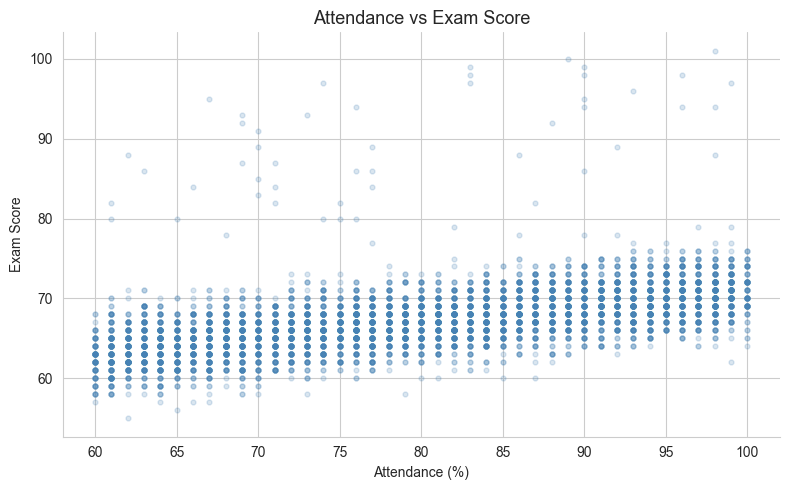

In [3]:
# Chart 1 — Attendance vs Exam Score
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Attendance'], df['Exam_Score'],
           alpha=0.2, color='steelblue', s=12)

m, b = pd.Series(df['Attendance']).corr(df['Exam_Score']), None
z = pd.Series(df['Attendance'])
ax.set_title('Attendance vs Exam Score', fontsize=13)
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Exam Score')
sns.despine()
plt.tight_layout()
plt.show()

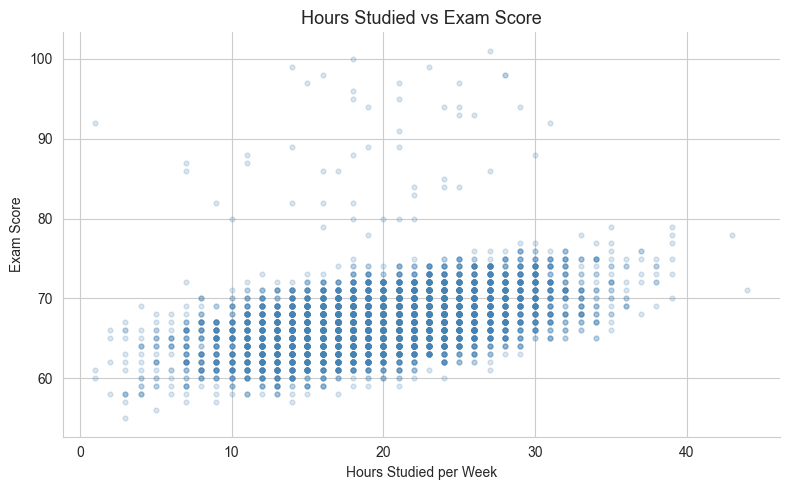

In [4]:
# Chart 2 — Hours Studied vs Exam Score
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Hours_Studied'], df['Exam_Score'],
           alpha=0.2, color='steelblue', s=12)

ax.set_title('Hours Studied vs Exam Score', fontsize=13)
ax.set_xlabel('Hours Studied per Week')
ax.set_ylabel('Exam Score')
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation — Sub-topic 1

- Both scatterplots confirm the correlation found in the EDA: higher attendance and more study hours are associated with higher exam scores.
- The relationship is more pronounced for `Attendance` — the upward trend is clearer and more consistent across the range.
- `Hours_Studied` shows a positive trend but with more spread, suggesting other factors also play a role.
- Both patterns align with the Pearson correlations calculated earlier (0.58 and 0.45 respectively).

---
## Sub-topic 2 — Social & Family Factors

`Family_Income`, `Parental_Involvement`, and `Access_to_Resources` all showed small but positive correlations with `Exam_Score` in the EDA. This sub-topic asks: does socioeconomic background play a measurable role in exam performance, even if the correlation is weak?

**Chart type choice:** Bar chart — these variables are categorical (Low / Medium / High). A bar chart showing the average exam score per category is the clearest way to compare groups. The ordered categories (Low → Medium → High) make a bar chart natural, as the viewer expects a visual progression.

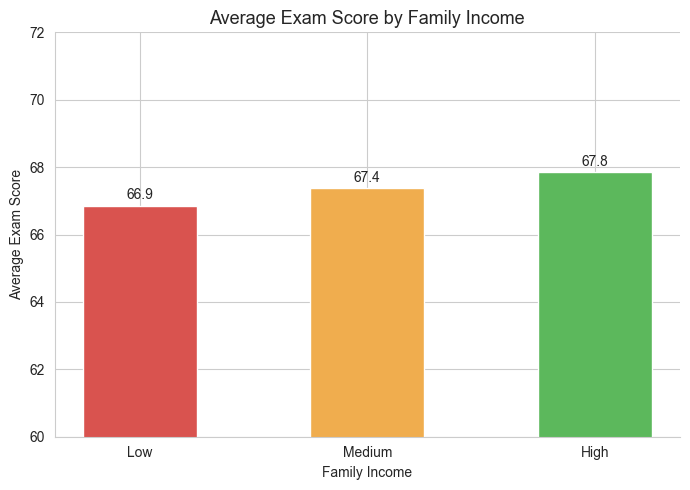

In [5]:
# Chart 3 — Avg Exam Score by Family Income
order = ['Low', 'Medium', 'High']
avg = df.groupby('Family_Income')['Exam_Score'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(order, avg, color=['#d9534f', '#f0ad4e', '#5cb85c'], width=0.5)
ax.set_ylim(60, 72)
ax.set_title('Average Exam Score by Family Income', fontsize=13)
ax.set_xlabel('Family Income')
ax.set_ylabel('Average Exam Score')

for i, val in enumerate(avg):
    ax.text(i, val + 0.1, f'{val:.1f}', ha='center', va='bottom', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

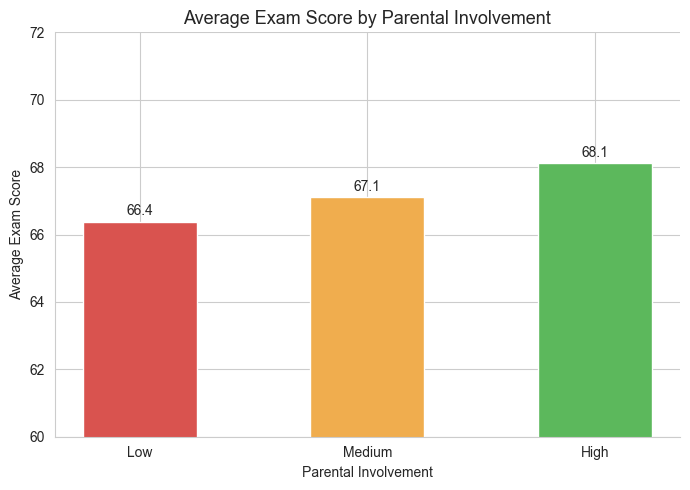

In [6]:
# Chart 4 — Avg Exam Score by Parental Involvement
avg2 = df.groupby('Parental_Involvement')['Exam_Score'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(order, avg2, color=['#d9534f', '#f0ad4e', '#5cb85c'], width=0.5)
ax.set_ylim(60, 72)
ax.set_title('Average Exam Score by Parental Involvement', fontsize=13)
ax.set_xlabel('Parental Involvement')
ax.set_ylabel('Average Exam Score')

for i, val in enumerate(avg2):
    ax.text(i, val + 0.1, f'{val:.1f}', ha='center', va='bottom', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation — Sub-topic 2

- Both charts show a clear step-up pattern: higher family income and higher parental involvement are consistently associated with higher average exam scores.
- Despite the relatively low Pearson correlations found in the EDA, the group differences are visible and follow the expected direction.
- This suggests that socioeconomic background does play a role, even if it is not the dominant factor compared to `Attendance`.
- A bar chart is appropriate here because it shows the average per category clearly — however, it hides within-group variability, which will be addressed in sub-topic 3 using boxplots.

---
## Sub-topic 3 — Personal & Motivational Factors

`Motivation_Level` and `Peer_Influence` showed low-to-moderate correlations in the EDA. This sub-topic checks whether attitude and social environment have a consistent effect on exam performance — or whether the distributions overlap heavily between groups.

**Chart type choice:** Boxplot — like sub-topic 2, these are categorical variables. However, here we use boxplots instead of bar charts because we are interested not just in the average but in the *full distribution* per group. Given the weak correlations, we expect overlap between groups — a boxplot makes this visible, which a bar chart would hide.

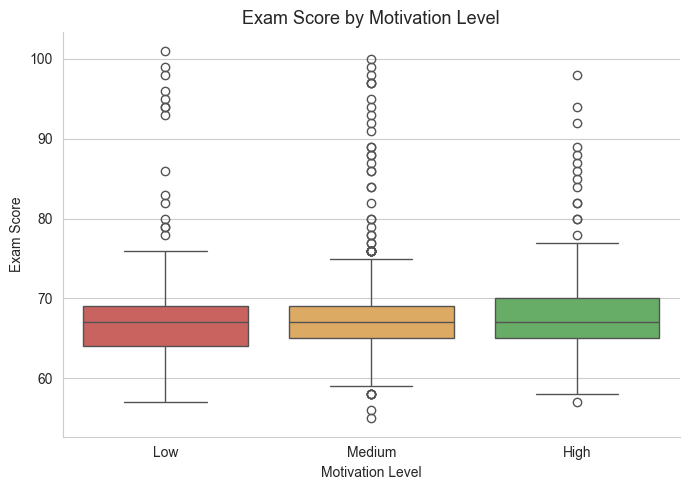

In [7]:
# Chart 5 — Exam Score by Motivation Level
order_mot = ['Low', 'Medium', 'High']

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score',
            order=order_mot, hue='Motivation_Level',
            palette=['#d9534f', '#f0ad4e', '#5cb85c'],
            legend=False, ax=ax)
ax.set_title('Exam Score by Motivation Level', fontsize=13)
ax.set_xlabel('Motivation Level')
ax.set_ylabel('Exam Score')
sns.despine()
plt.tight_layout()
plt.show()

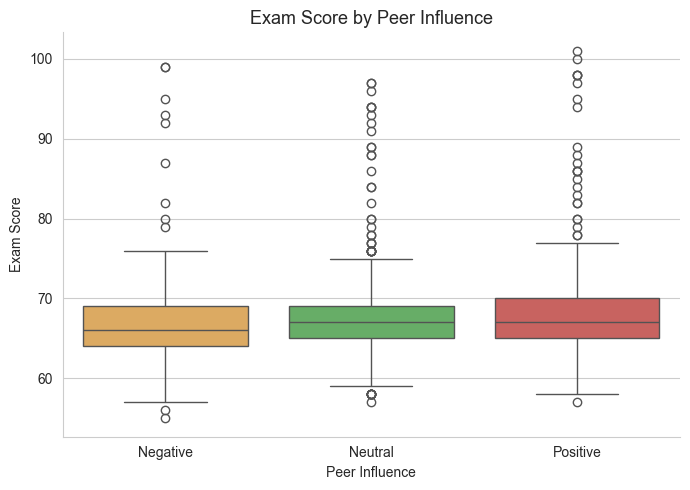

In [8]:
# Chart 6 — Exam Score by Peer Influence
order_peer = ['Negative', 'Neutral', 'Positive']

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Peer_Influence', y='Exam_Score',
            order=order_peer, hue='Peer_Influence',
            palette=['#d9534f', '#f0ad4e', '#5cb85c'],
            legend=False, ax=ax)
ax.set_title('Exam Score by Peer Influence', fontsize=13)
ax.set_xlabel('Peer Influence')
ax.set_ylabel('Exam Score')
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation — Sub-topic 3

- Both boxplots show a visible but modest shift in exam scores across categories.
- The boxes overlap substantially between groups — confirming the weak correlations found in the EDA.
- Higher motivation and positive peer influence do tend to produce slightly higher scores, but the effect is not as strong or consistent as `Attendance`.
- The boxplot is the right choice here: it reveals that the differences are real but small, and that individual variation within each group is high.

---
## Summary — Which factor matters most?

Connecting back to the full correlation ranking from the EDA, this final chart ranks all factors by their absolute correlation with `Exam_Score`.

### Final Interpretation

- `Attendance` is clearly the dominant factor — with a correlation of 0.58 it stands well above all other variables.
- `Hours_Studied` is the second strongest factor at 0.45, confirming that active learning behavior matters.
- Social and motivational factors (`Family_Income`, `Parental_Involvement`, `Motivation_Level`, `Peer_Influence`) all show small but consistent positive correlations, suggesting they play a secondary supporting role.
- Demographic variables (`Gender`, `School_Type`, `Distance_from_Home`) show near-zero correlations, meaning they have little to no predictive power for exam scores in this dataset.

**Conclusion:** The data suggests that behavioral factors — especially showing up and studying — have the greatest influence on student exam performance. Background and motivational factors matter, but to a much lesser degree.